In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'  

https://archive.ics.uci.edu/dataset/468/online+shoppers+purchasing+intention+dataset

## 1.Load Dataset

In [2]:
df = pd.read_csv(r"C:\Users\HP\Downloads\online+shoppers+purchasing+intention+dataset\online_shoppers_intention.csv")
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [3]:
df_backup = df
df_backup

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.000000,0.100000,0.000000,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.050000,0.140000,0.000000,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.020000,0.050000,0.000000,0.0,Feb,3,3,1,4,Returning_Visitor,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12325,3,145.0,0,0.0,53,1783.791667,0.007143,0.029031,12.241717,0.0,Dec,4,6,1,1,Returning_Visitor,True,False
12326,0,0.0,0,0.0,5,465.750000,0.000000,0.021333,0.000000,0.0,Nov,3,2,1,8,Returning_Visitor,True,False
12327,0,0.0,0,0.0,6,184.250000,0.083333,0.086667,0.000000,0.0,Nov,3,2,1,13,Returning_Visitor,True,False
12328,4,75.0,0,0.0,15,346.000000,0.000000,0.021053,0.000000,0.0,Nov,2,2,3,11,Returning_Visitor,False,False


## 2.Exploratory Data Analysis

In [4]:
df.shape

(12330, 18)

In [5]:
#check the entire dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [6]:
#get the column names of dataset
df.columns

Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType',
       'Weekend', 'Revenue'],
      dtype='object')

### Explanation about each column:
- "Administrative", "Administrative Duration", "Informational", "Informational Duration", "Product Related" and "Product Related Duration" represent the number of different types of pages visited by the visitor in that session and total time spent in each of these page categories.
- The values of these features are derived from the URL information of the pages visited by the user and updated in real time when a user takes an action, e.g. moving from one page to another.
- The "Bounce Rate", "Exit Rate" and "Page Value" features represent the metrics measured by "Google Analytics" for each page in the e-commerce site. The value of "Bounce Rate" feature for a web page refers to the percentage of visitors who enter the site from that page and then leave ("bounce") without triggering any other requests to the analytics server during that session.
- The value of "Exit Rate" feature for a specific web page is calculated as for all pageviews to the page, the percentage that were the last in the session. The "Page Value" feature represents the average value for a web page that a user visited before completing an e-commerce transaction.
-  The "Special Day" feature indicates the closeness of the site visiting time to a specific special day (e.g. Mother’s Day, Valentine's Day) in which the sessions are more likely to be finalized with transaction.
-  The value of this attribute is determined by considering the dynamics of e-commerce such as the duration between the order date and delivery date. For example, for Valentina’s day, this value takes a nonzero value between February 2 and February 12, zero before and after this date unless it is close to another special day, and its maximum value of 1 on February 8. 

In [7]:
# Outliers 
df.describe(percentiles=[0.05,0.10,0.15,0.20,0.25,0.50,0.75,0.80,0.85,0.90,0.95])

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
5%,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.004568,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
10%,0.000000,0.000000,0.000000,0.000000,3.000000,36.000000,0.000000,0.007449,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
15%,0.000000,0.000000,0.000000,0.000000,4.000000,77.000000,0.000000,0.010000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
20%,0.000000,0.000000,0.000000,0.000000,6.000000,129.000000,0.000000,0.012071,0.000000,0.000000,1.000000,2.000000,1.000000,2.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000


In [8]:
num_cols = df.select_dtypes(exclude='object').columns
print(f"Numerical_columns:", num_cols)
print("___"*30)
cat_cols = df.select_dtypes(include='object').columns
print(f"categorical_columns:", cat_cols)

Numerical_columns: Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'Weekend',
       'Revenue'],
      dtype='object')
__________________________________________________________________________________________
categorical_columns: Index(['Month', 'VisitorType'], dtype='object')


In [9]:
df['Month'].value_counts()
print(f"*"*30)
df['VisitorType'].value_counts()

Month
May     3364
Nov     2998
Mar     1907
Dec     1727
Oct      549
Sep      448
Aug      433
Jul      432
June     288
Feb      184
Name: count, dtype: int64

******************************


VisitorType
Returning_Visitor    10551
New_Visitor           1694
Other                   85
Name: count, dtype: int64

### Observation: 
1. Most users visited the website in May and November, so these months have the highest traffic.

2. Most visitors are returning visitors, which means people who have already visited the website before.

In [10]:
#Missing values
df.isna().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

### Obseravtion: 
1. There are no missing values in any column,
2. which means the dataset is complete and does not require missing value handling before analysis or model training

In [11]:
#Duplicate observations
df.duplicated().sum()

125

In [12]:
df = df.drop_duplicates()
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [13]:
df.reset_index(drop=True, inplace=True)

In [14]:
df.duplicated().sum()

0

### Observation:
* There are 125 duplicate records in the dataset
* Which should be removed to avoid bias and ensure accurate analysis and model performance

In [15]:
df.shape

(12205, 18)

In [16]:
#dtypes of all columns
df.dtypes

#count of variables by there dtype
df.dtypes.value_counts()

#unique values in the columns
df.select_dtypes(include='object').nunique()

Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                       object
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                 object
Weekend                       bool
Revenue                       bool
dtype: object

int64      7
float64    7
object     2
bool       2
Name: count, dtype: int64

Month          10
VisitorType     3
dtype: int64

## Target Variable Analysis 

**Revenue** indicates the visitor completed a purchase or not.

In [17]:
df['Revenue'].unique()
df['Revenue'].value_counts(normalize=True) 

array([False,  True])

Revenue
False    0.843671
True     0.156329
Name: proportion, dtype: float64

- By the value counts , there is a class imbalence in the taregt variable

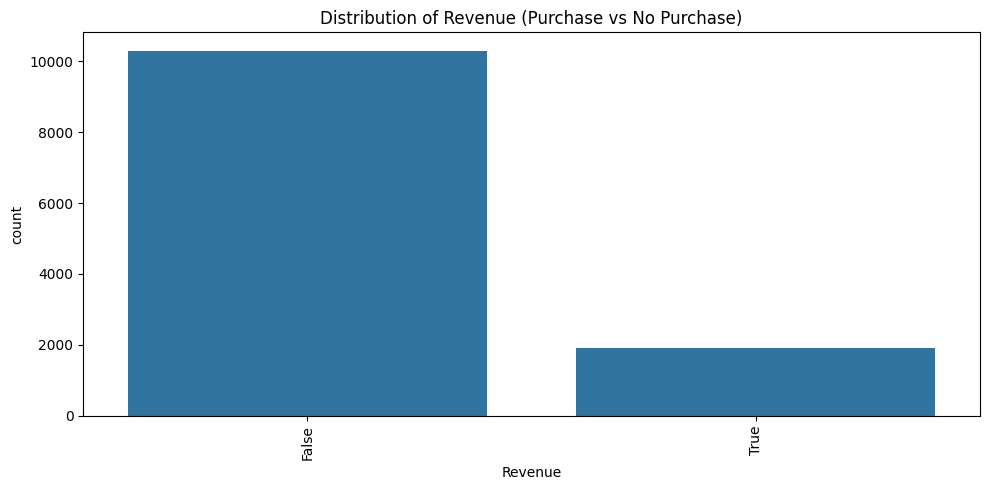

In [18]:
fig, ax = plt.subplots(figsize=(10,5))
sns.countplot(data=df, x='Revenue', ax=ax)
ax.set_title("Distribution of Revenue (Purchase vs No Purchase)")
ax.tick_params(axis='x', rotation=90)
plt.tight_layout()
plt.show();

## 1.Univariate Analysis

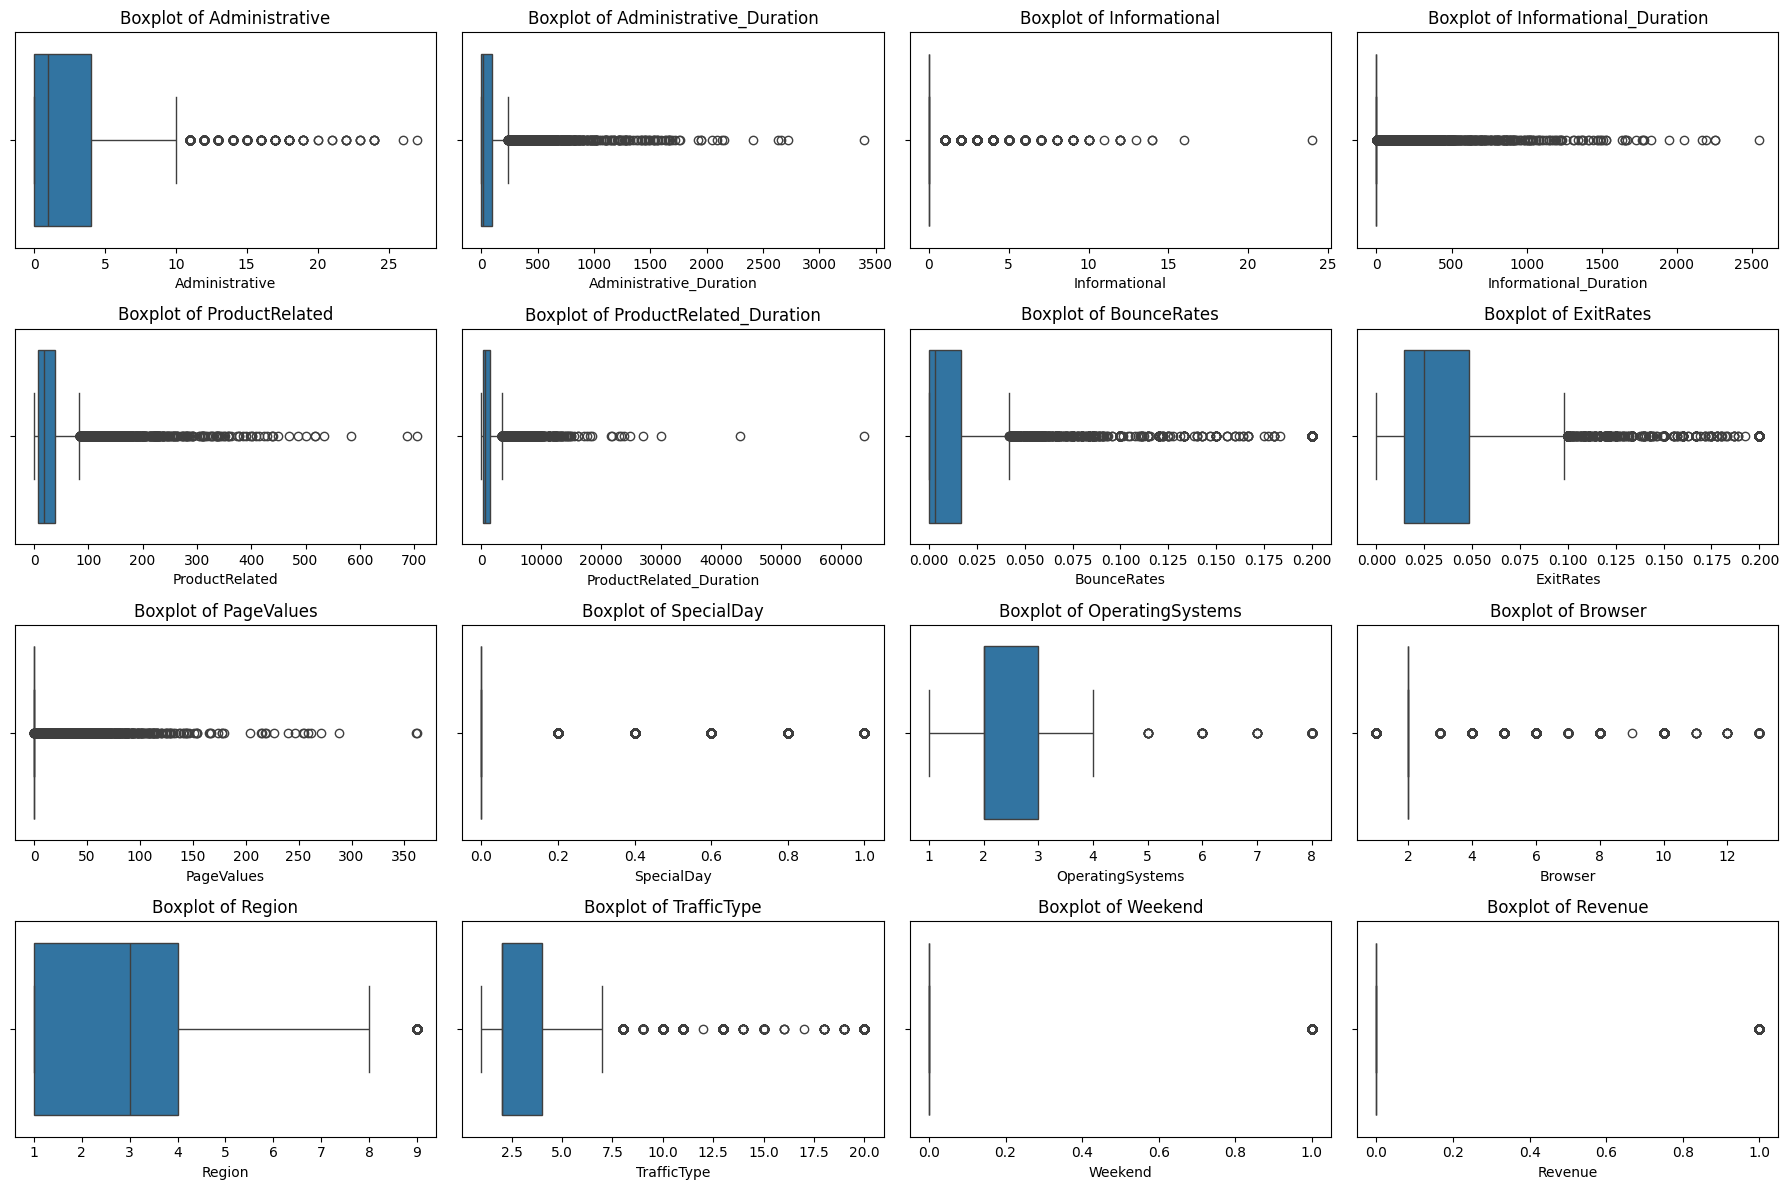

In [19]:
plt.figure(figsize=(18,12))

for i, col in enumerate(num_cols):
    plt.subplot(4,4,i+1)
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")

plt.tight_layout()
plt.show();

#### Observation:
- Presence of huge number of outliers in the columns `'Administrative_Duration','Informational_Duration','ProductRelated' and few other columns`

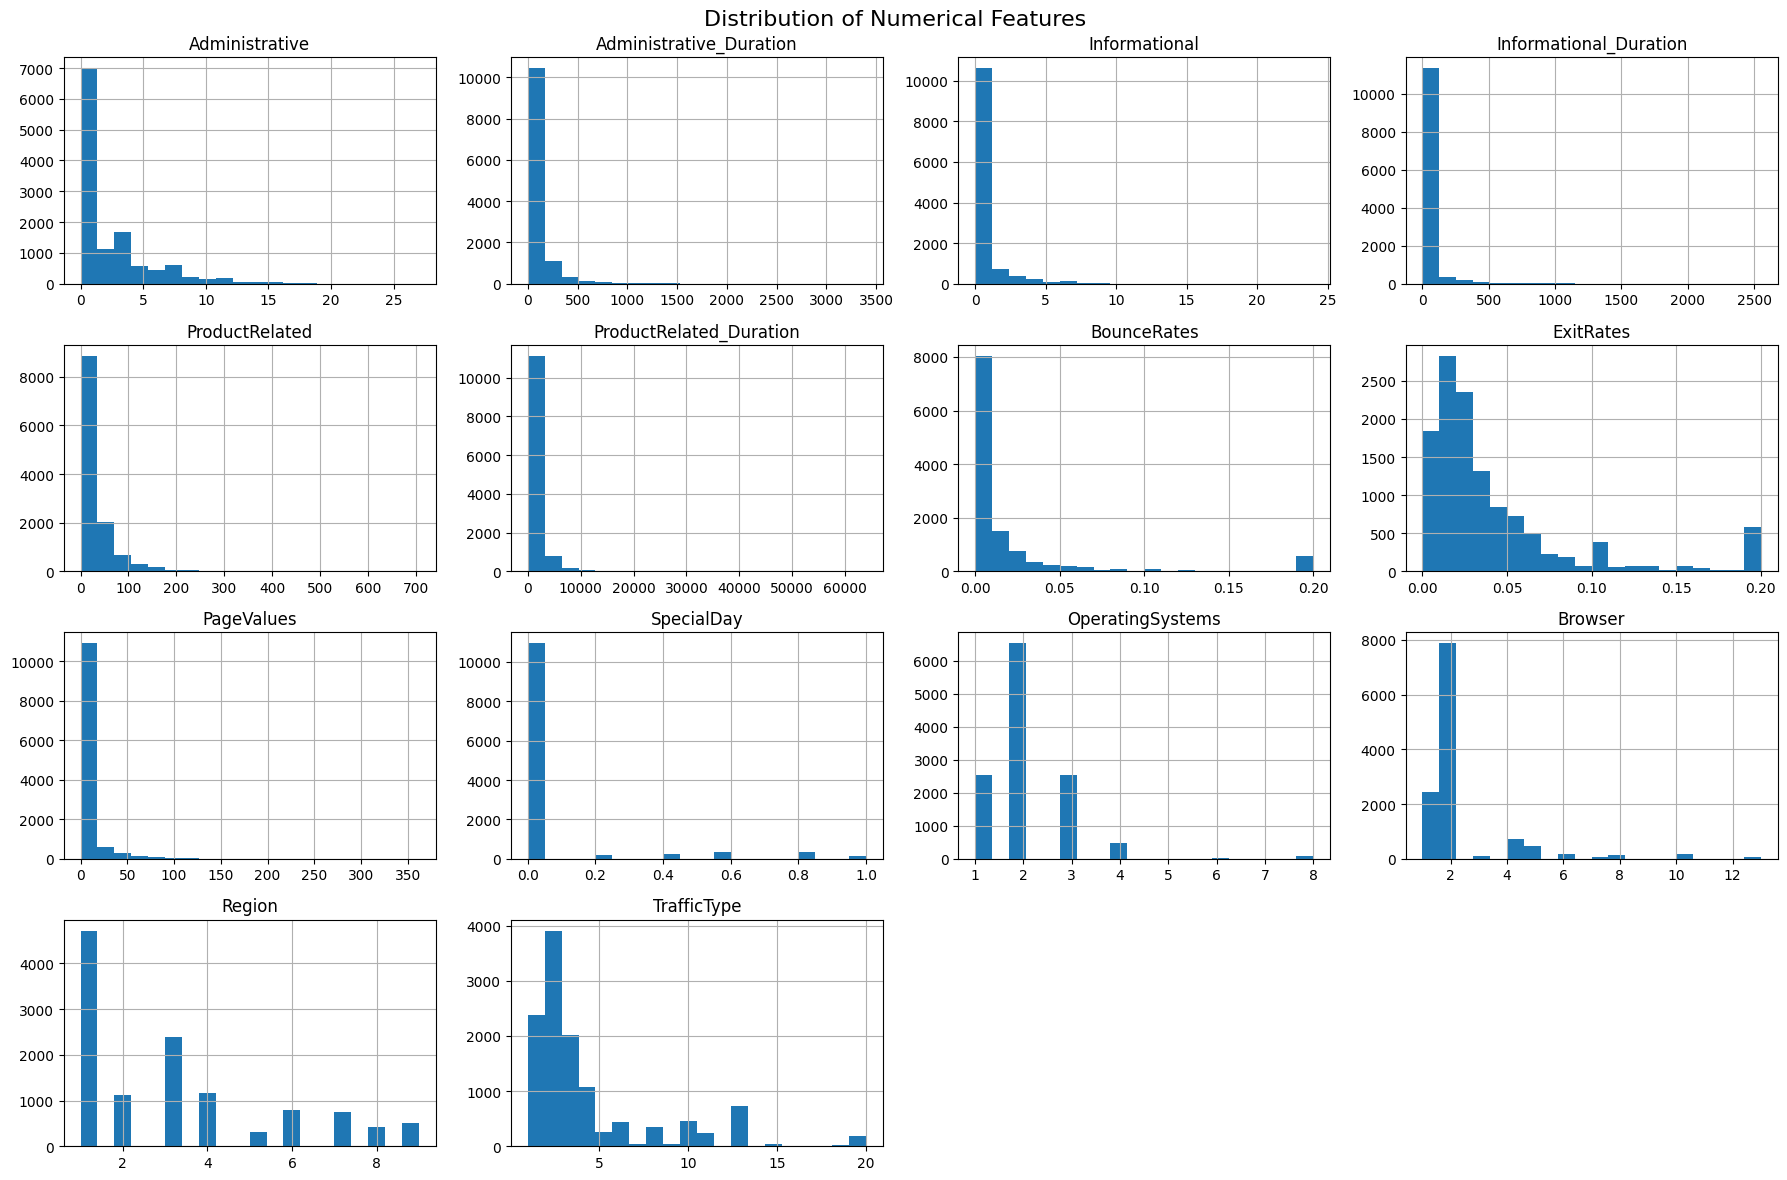

In [20]:
# Numerical Distributions
df[num_cols].hist(figsize=(18,12), bins=20)
plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show();

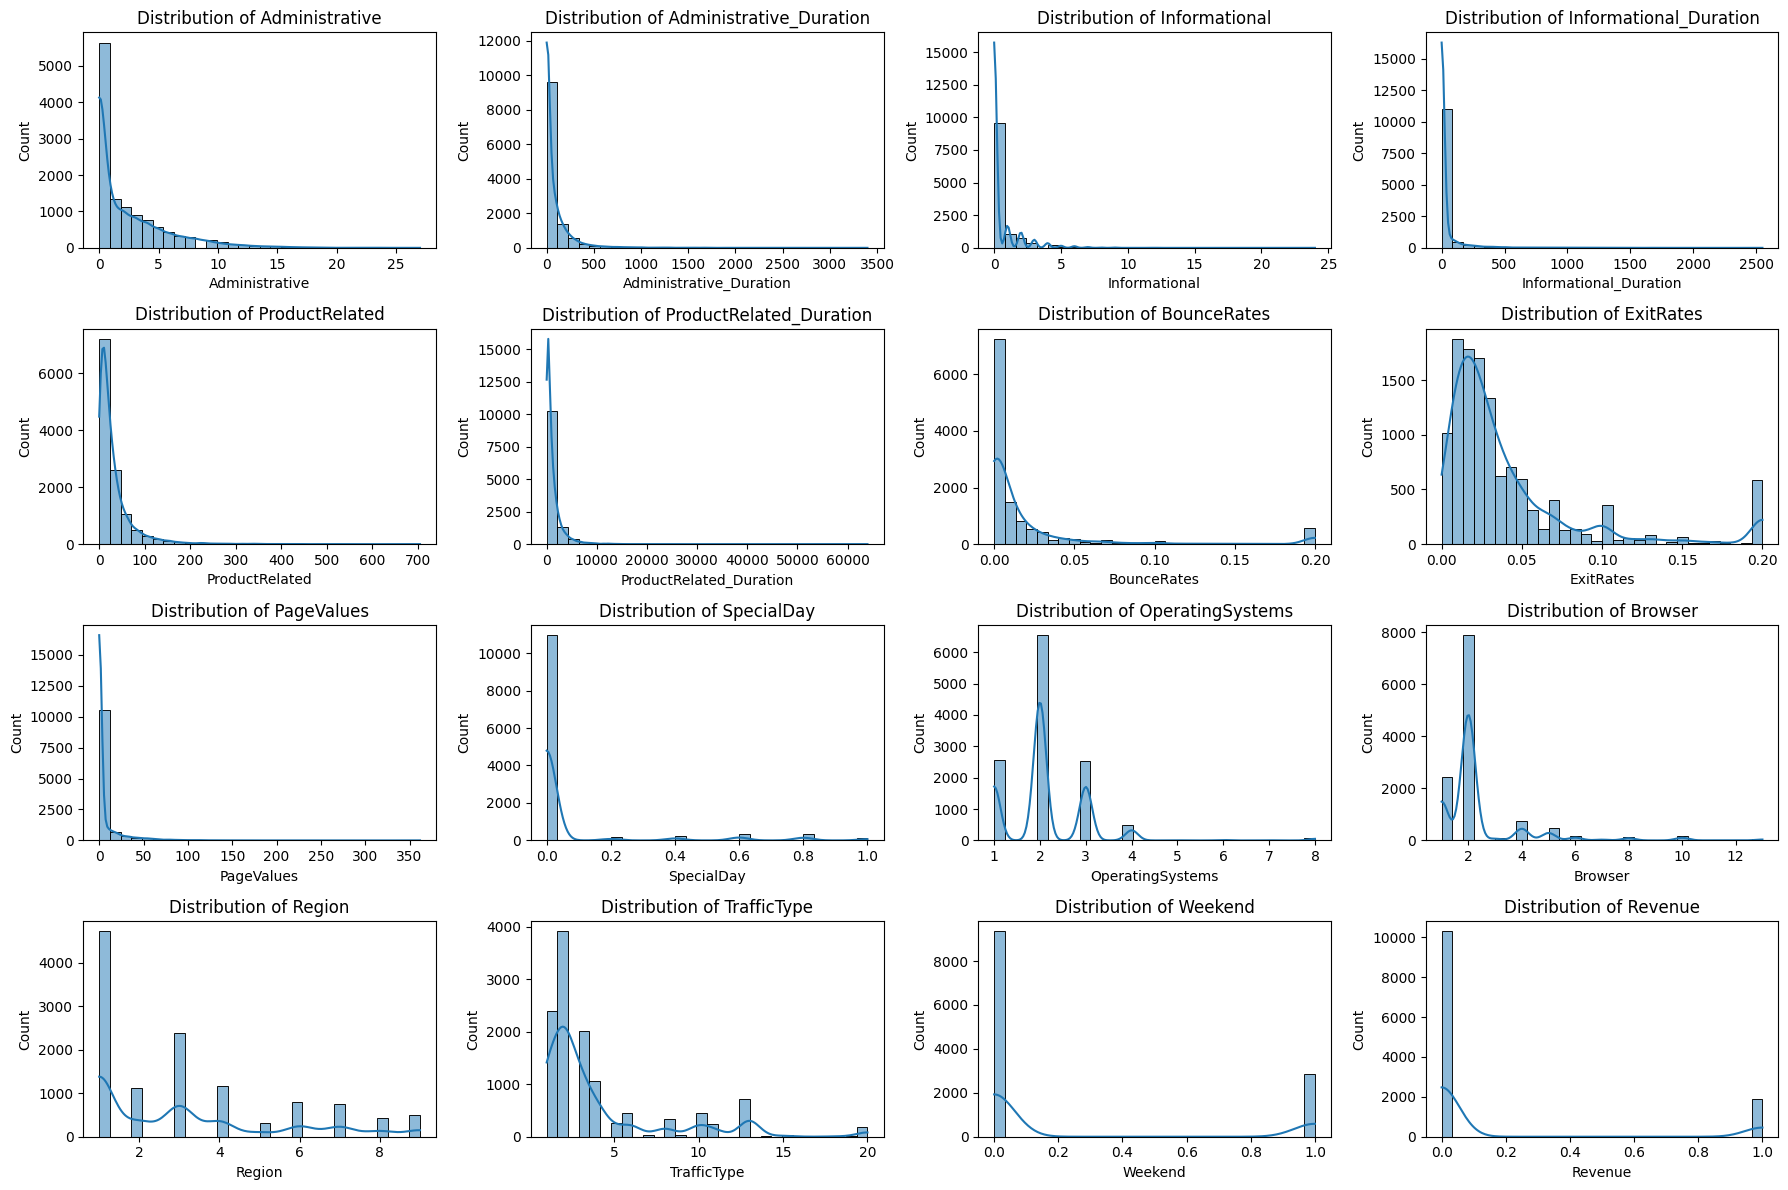

In [21]:
plt.figure(figsize=(18,12))

for i, col in enumerate(num_cols):
    plt.subplot(4,4,i+1)
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f"Distribution of {col}")

plt.tight_layout()
plt.show();

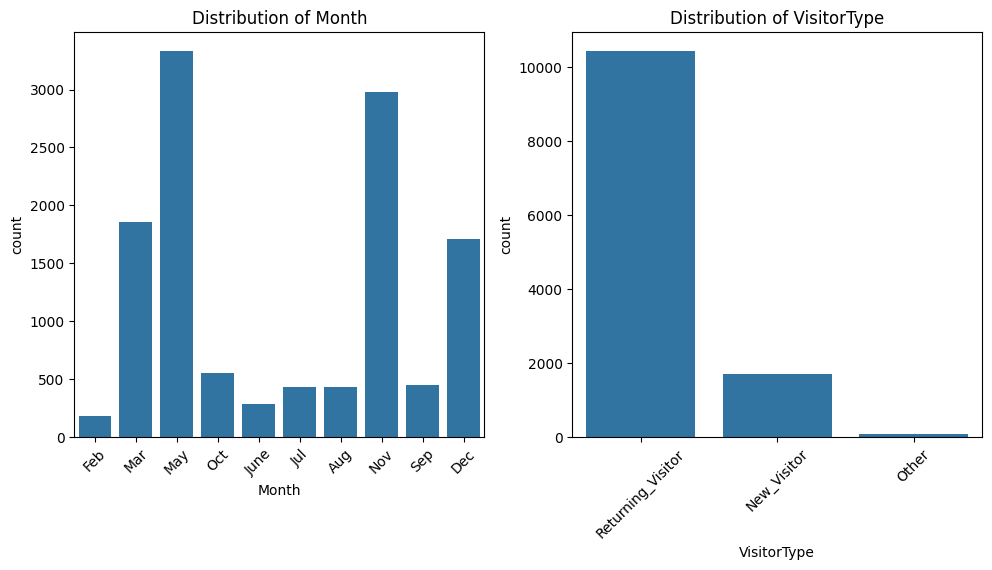

In [22]:
plt.figure(figsize=(15,10))

for i, col in enumerate(cat_cols):
    plt.subplot(2,3,i+1)
    sns.countplot(data=df, x=col)
    plt.xticks(rotation=45)
    plt.title(f"Distribution of {col}")

plt.tight_layout()
plt.show();

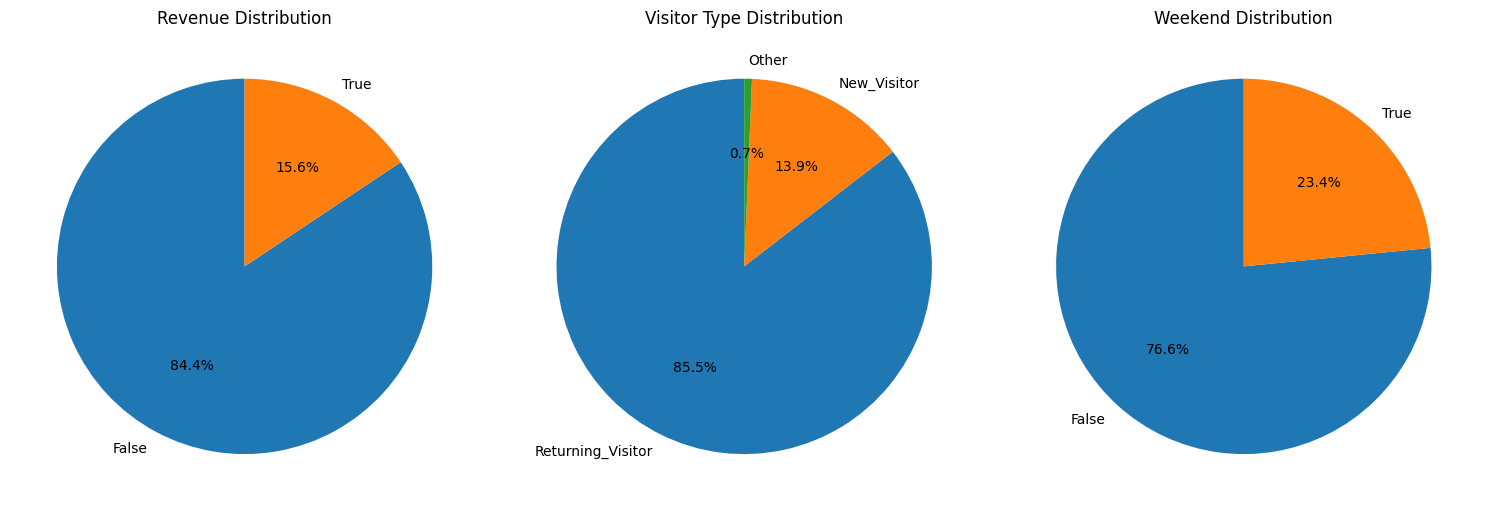

In [23]:
plt.figure(figsize=(15,5))

# Revenue pie chart
plt.subplot(1,3,1)
revenue_counts = df['Revenue'].value_counts()
plt.pie(revenue_counts, labels=revenue_counts.index, autopct='%1.1f%%', startangle=90)
plt.title("Revenue Distribution")

# VisitorType pie chart
plt.subplot(1,3,2)
visitor_counts = df['VisitorType'].value_counts()
plt.pie(visitor_counts, labels=visitor_counts.index, autopct='%1.1f%%', startangle=90)
plt.title("Visitor Type Distribution")

# Weekend pie chart
plt.subplot(1,3,3)
weekend_counts = df['Weekend'].value_counts()
plt.pie(weekend_counts, labels=weekend_counts.index, autopct='%1.1f%%', startangle=90)
plt.title("Weekend Distribution")

plt.tight_layout()
plt.show(); 

## 2.Bivariate Analysis 

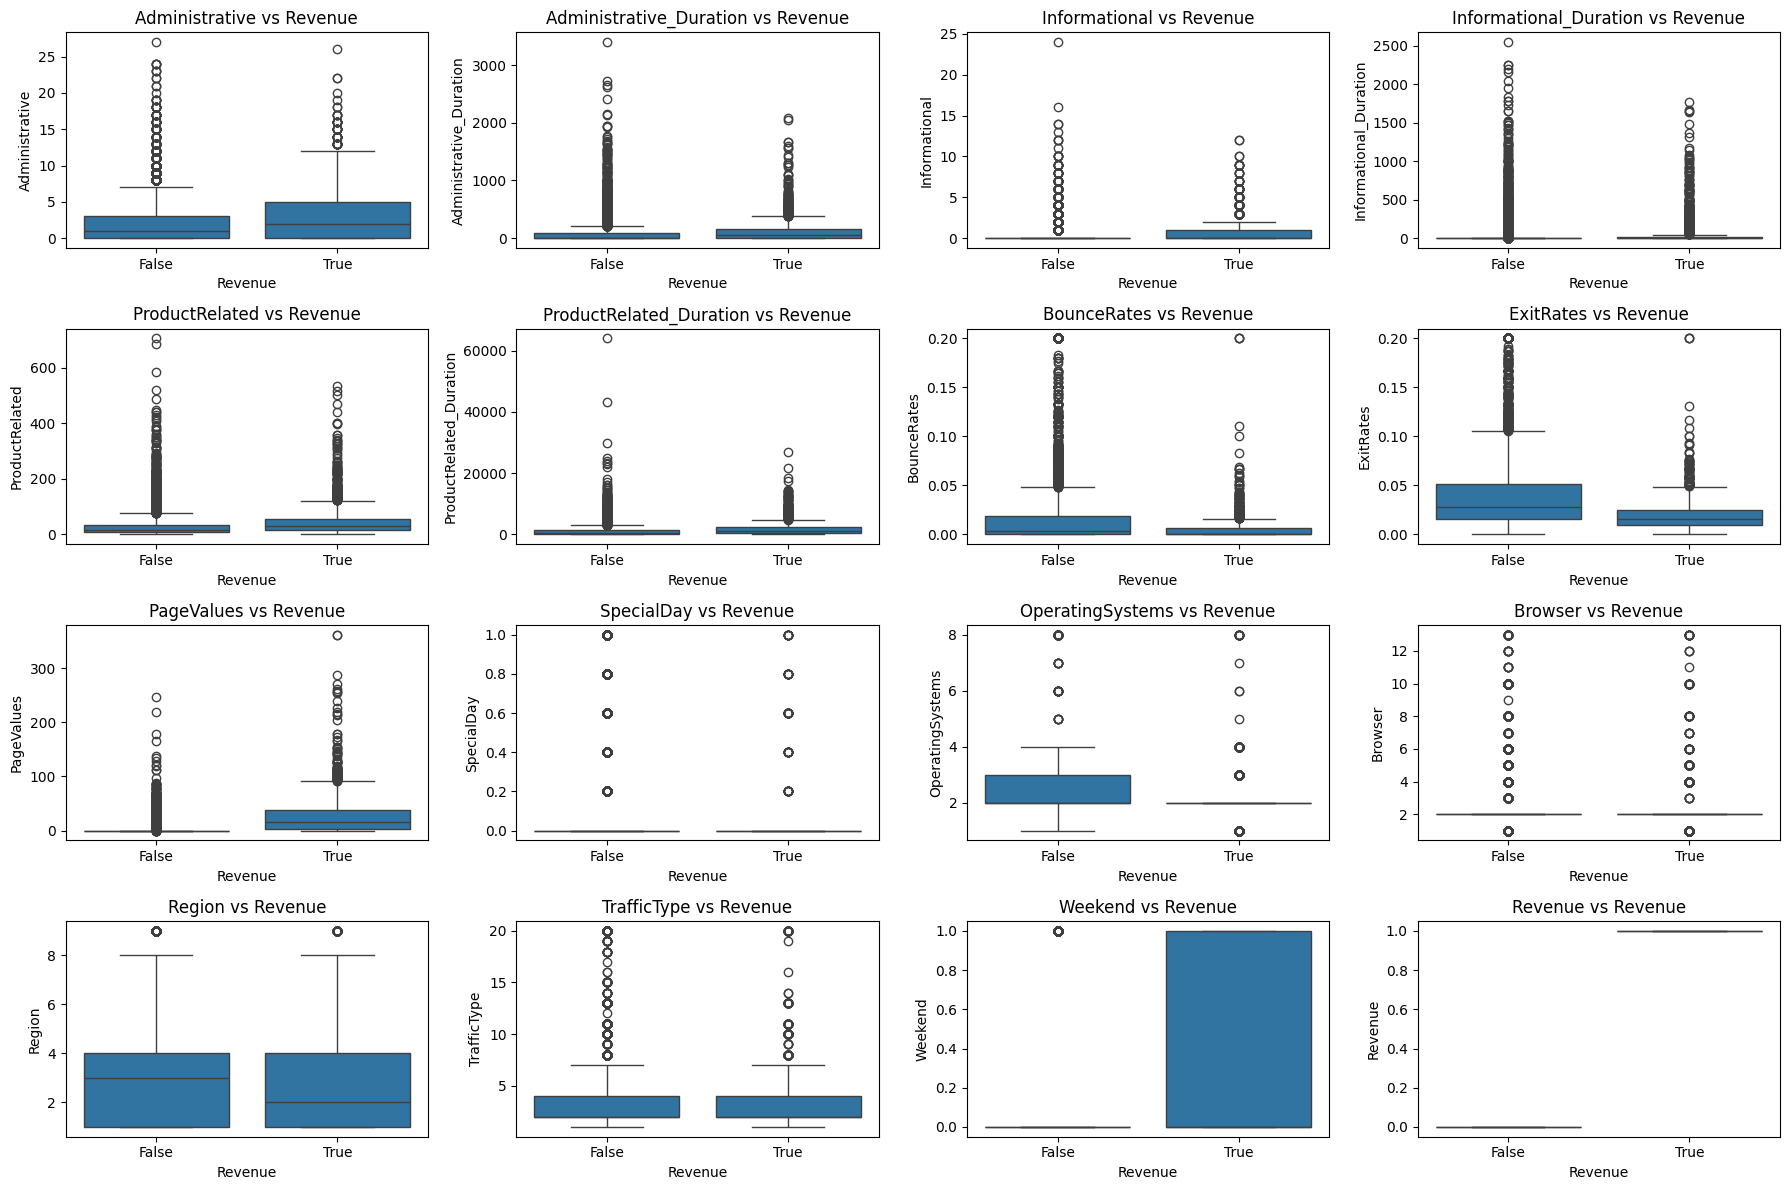

In [24]:
plt.figure(figsize=(18,12))

for i, col in enumerate(num_cols):
    plt.subplot(4,4,i+1)
    sns.boxplot(x='Revenue', y=col, data=df)
    plt.title(f"{col} vs Revenue")

plt.tight_layout()
plt.show();

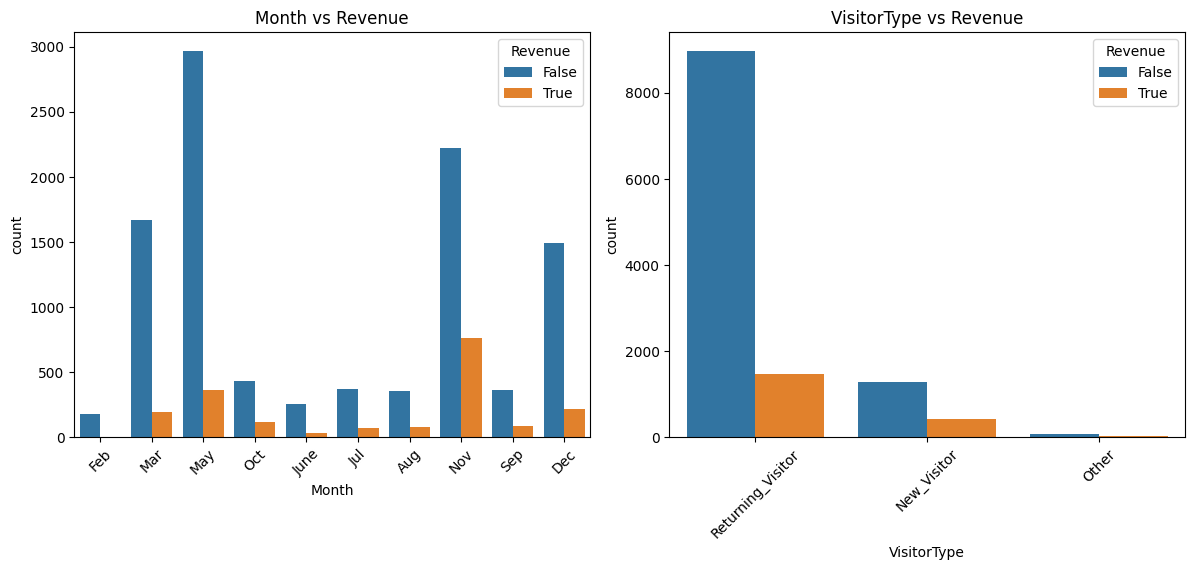

In [25]:
plt.figure(figsize=(18,10))

for i, col in enumerate(cat_cols):
    plt.subplot(2,3,i+1)
    sns.countplot(x=col, hue='Revenue', data=df)
    plt.xticks(rotation=45)
    plt.title(f"{col} vs Revenue")

plt.tight_layout()
plt.show();

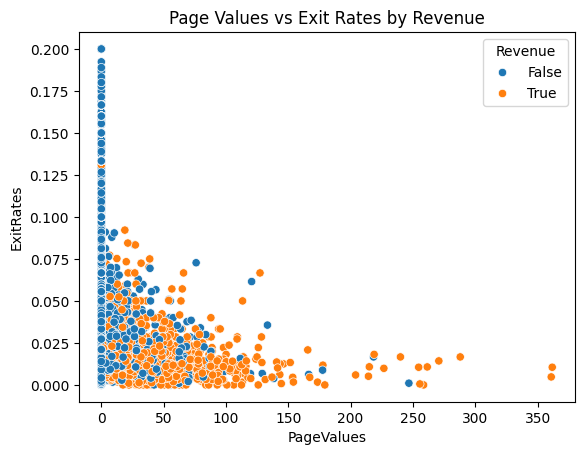

In [26]:
sns.scatterplot(x='PageValues', y='ExitRates', hue='Revenue', data=df)
plt.title("Page Values vs Exit Rates by Revenue")
plt.show();

## 3.Multivariate Analysis 

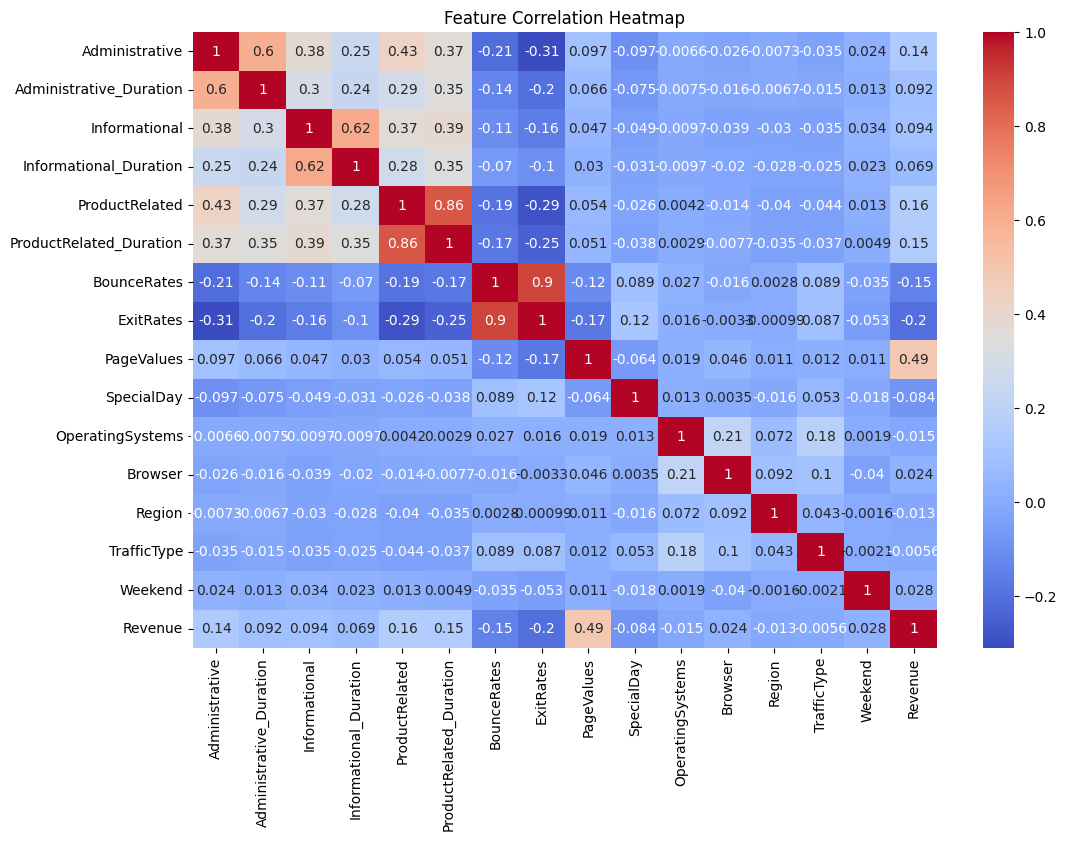

In [27]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show();

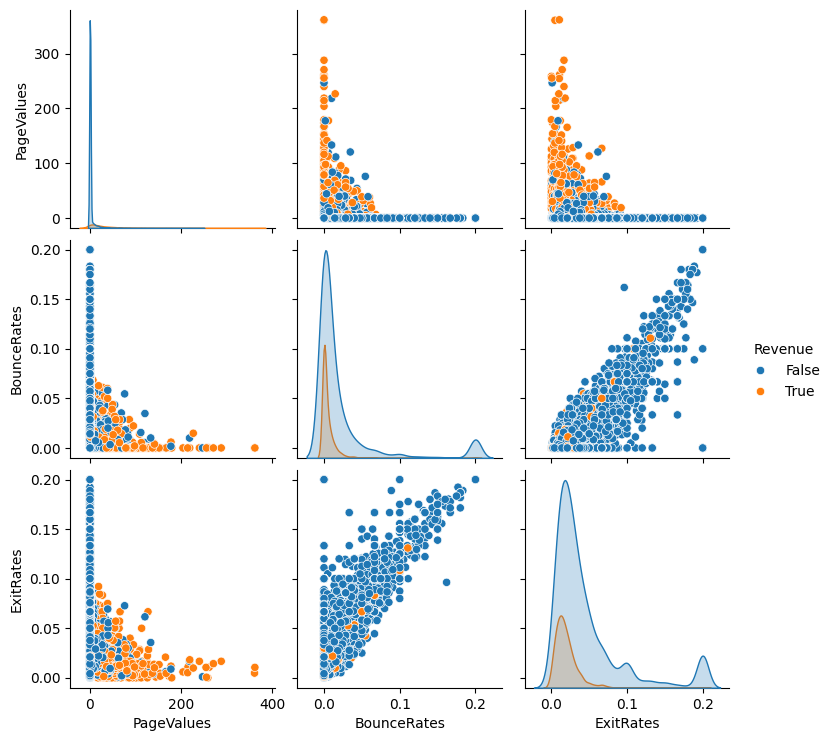

In [28]:
sns.pairplot(df[['PageValues','BounceRates','ExitRates','Revenue']], hue='Revenue')
plt.show();

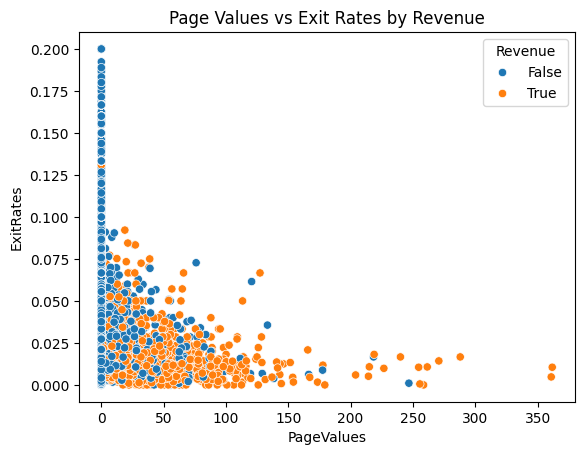

In [29]:
sns.scatterplot(x='PageValues', y='ExitRates', hue='Revenue', data=df)
plt.title("Page Values vs Exit Rates by Revenue")
plt.show();

In [30]:
#from sklearn.ensemble import IsolationForest
#iso = IsolationForest(
#    n_estimators=100,
#    contamination=0.05,
#    random_state=42
#)
#outliers = iso.fit_predict(df[num_cols])

In [31]:
#df['Outlier'] = outliers
#df['Outlier'].value_counts()

In [32]:
#df_new = df[df['Outlier']==1]

In [33]:
#df_new.drop('Outlier',axis=1)

In [34]:
#print(df_new.shape,df.shape)

In [35]:
df['Weekend'] = df['Weekend'].astype('int')
# Binary no need of usinf Label encoder
df['Revenue'] = df['Revenue'].astype('int')

## ML PIPELINE

In [36]:
from imblearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import classification_report


from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import cross_val_score,StratifiedKFold

### Step 3 - Identify input and output

In [37]:
X = df.drop('Revenue',axis=1)
y = df['Revenue']
X.shape,y.shape

((12205, 17), (12205,))

### Step 4 - Split the data into Train and Test

In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 42,stratify=y)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((9764, 17), (2441, 17), (9764,), (2441,))

In [39]:
X_train.columns

Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType',
       'Weekend'],
      dtype='object')

### Step 5 - Data Preparation for X_train

In [40]:
from sklearn.preprocessing import MinMaxScaler,RobustScaler
rs = RobustScaler().set_output(transform='pandas')
rs

RobustScaler()

- There are outliers in the dataset , `RobustScaler` best suitable for scaling

In [41]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(sparse_output=False,drop='first').set_output(transform='pandas')
ohe

OneHotEncoder(drop='first', sparse_output=False)

- No ordinal columns , using OneHotEncoder for categorical feature encoding

In [42]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
skf

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)

- For binary classification  using StratifiedKFold to check the cross validation score for overfitting detection

#### Step 6 -Applying smote

In [43]:
#from imblearn.over_sampling import SMOTE
#smote = SMOTE(random_state=42)

In [44]:
#Num_cols = df_new.select_dtypes(include=['int','float']).columns
#Num_cols

In [45]:
#Cat_cols = df_new.select_dtypes(include=['object']).columns
#Cat_cols

In [46]:
Bool_cols = df.select_dtypes(include='bool').columns
Bool_cols

Index([], dtype='object')

In [47]:
num_cols = num_cols[:-1]

In [48]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', rs , num_cols,),
        ('cat', ohe, cat_cols),
    ]
)

In [49]:
pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', DecisionTreeClassifier())
])

**DT**

In [50]:
from sklearn.tree import DecisionTreeClassifier

In [51]:
dt = DecisionTreeClassifier()

In [52]:
pipeline.fit(X_train,y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', RobustScaler(),
                                                  Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'Weekend'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                sparse_output=False),
                                                  Index(['Month', 'VisitorType'], dtype='object'))])),
                ('model', DecisionTreeClassifier())])

In [53]:
y_pred = pipeline.predict(X_test)
y_pred

array([0, 0, 0, ..., 1, 0, 0])

In [54]:
val_score = cross_val_score(pipeline,X_train,y_train,cv=skf)
print(val_score.mean())

0.8583578332619846


In [55]:
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

           0       0.91      0.92      0.92      2050
           1       0.56      0.55      0.56       391

    accuracy                           0.86      2441
   macro avg       0.74      0.73      0.74      2441
weighted avg       0.86      0.86      0.86      2441



**KNN**

In [56]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()
knn

KNeighborsClassifier()

In [57]:
pipeline = Pipeline([
    ('preprocessing', preprocessor),
   ('model', KNeighborsClassifier())
])

In [58]:
pipeline.fit(X_train,y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', RobustScaler(),
                                                  Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'Weekend'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                sparse_output=False),
                                                  Index(['Month', 'VisitorType'], dtype='object'))])),
                ('model', KNeighborsClassifier())])

In [59]:
y_pred_knn = pipeline.predict(X_test)
y_pred_knn

array([0, 0, 0, ..., 1, 0, 0])

In [60]:
val_score = cross_val_score(pipeline,X_train,y_train,cv=skf)
print(val_score.mean())

0.8785332884255412


In [61]:
print(classification_report(y_pred_knn,y_test))

              precision    recall  f1-score   support

           0       0.94      0.91      0.93      2116
           1       0.53      0.62      0.57       325

    accuracy                           0.88      2441
   macro avg       0.73      0.77      0.75      2441
weighted avg       0.89      0.88      0.88      2441



In [62]:
models = {
    "Decision Tree": DecisionTreeClassifier(),
    "KNN": KNeighborsClassifier(),
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "SVM": SVC(),
    "Naive Bayes": GaussianNB(),
    "Random Forest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(eval_metric='logloss')
}

In [63]:
results = {}
for name, model in models.items():
    pipeline = Pipeline(steps=[
        ('preprocess', preprocessor),
        ('model', model)
    ])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    print(name, "classification Report:")
    print(classification_report(y_pred,y_test))
    print(f'Validation score for  {name} : ',np.mean(cross_val_score(pipeline,X_train,y_train,cv=skf)))

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', RobustScaler(),
                                                  Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'Weekend'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                sparse_output=False),
                                                  Index(['Month', 'VisitorType'], dtype='object'))])),
                ('model', DecisionTreeClassifier())])

Decision Tree classification Report:
              precision    recall  f1-score   support

           0       0.92      0.92      0.92      2051
           1       0.57      0.55      0.56       390

    accuracy                           0.86      2441
   macro avg       0.74      0.74      0.74      2441
weighted avg       0.86      0.86      0.86      2441

Validation score for  Decision Tree :  0.8570273349953414


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', RobustScaler(),
                                                  Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'Weekend'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                sparse_output=False),
                                                  Index(['Month', 'VisitorType'], dtype='object'))])),
                ('model', KNeighborsClassifier())])

KNN classification Report:
              precision    recall  f1-score   support

           0       0.94      0.91      0.93      2116
           1       0.53      0.62      0.57       325

    accuracy                           0.88      2441
   macro avg       0.73      0.77      0.75      2441
weighted avg       0.89      0.88      0.88      2441

Validation score for  KNN :  0.8785332884255412


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', RobustScaler(),
                                                  Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'Weekend'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                sparse_output=False),
                                                  Index(['Month', 'VisitorType'], dtype='object'))])),
                ('model', LogisticRegression(max_iter=2000))])

...

Naive Bayes classification Report:
              precision    recall  f1-score   support

           0       0.71      0.96      0.81      1530
           1       0.82      0.34      0.49       911

    accuracy                           0.73      2441
   macro avg       0.77      0.65      0.65      2441
weighted avg       0.75      0.73      0.69      2441

Validation score for  Naive Bayes :  0.7185583549478315


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', RobustScaler(),
                                                  Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'Weekend'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                sparse_output=False),
                                                  Index(['Month', 'VisitorType'], dtype='object'))])),
                ('model', RandomForestClassifier())])

Random Forest classification Report:
              precision    recall  f1-score   support

           0       0.96      0.92      0.94      2139
           1       0.58      0.73      0.65       302

    accuracy                           0.90      2441
   macro avg       0.77      0.83      0.79      2441
weighted avg       0.91      0.90      0.91      2441

Validation score for  Random Forest :  0.9018846058606768


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', RobustScaler(),
                                                  Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'Weekend'],
      dtype='object')),...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

XGBoost classification Report:
              precision    recall  f1-score   support

           0       0.95      0.93      0.94      2092
           1       0.62      0.68      0.65       349

    accuracy                           0.89      2441
   macro avg       0.78      0.80      0.79      2441
weighted avg       0.90      0.89      0.90      2441

Validation score for  XGBoost :  0.8961494715989693


**HPT**

In [64]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
pipeline = Pipeline(steps=[
        ('preprocess', preprocessor),
        ('rf_model', rf)])

pipeline.fit(X_train,y_train)
y_pred = pipeline.predict(X_test)
print(classification_report(y_test, y_pred))
print(f'Validation score for  RF : ',np.mean(cross_val_score(pipeline,X_train,y_train,cv=skf)))

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', RobustScaler(),
                                                  Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'Weekend'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                sparse_output=False),
                                                  Index(['Month', 'VisitorType'], dtype='object'))])),
                ('rf_model',
                 RandomForestClassifier(class_weight='balanced',
                                        min_samples_leaf=2, n_estimators=300,
                                        n_jobs=-1, random_state=42))])

              precision    recall  f1-score   support

           0       0.94      0.95      0.94      2059
           1       0.70      0.67      0.68       382

    accuracy                           0.90      2441
   macro avg       0.82      0.81      0.81      2441
weighted avg       0.90      0.90      0.90      2441

Validation score for  RF :  0.9020901009795775


- No need of Hyper parameter tuning , default hyper parameters are giving best performance

### Saving the trained model into file

In [65]:
import joblib
joblib.dump(pipeline, "random_forest_customer.pkl")

['random_forest_customer.pkl']

In [66]:
loaded_model = joblib.load('random_forest_customer.pkl')
loaded_model

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', RobustScaler(),
                                                  Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'Weekend'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                sparse_output=False),
                                                  Index(['Month', 'VisitorType'], dtype='object'))])),
                ('rf_model',
                 RandomForestClassifier(class_weight='balanced',
                                        min_samples_leaf=2, n_estimators=300,
                                        n_jobs=-1, random_state=42))])